In [1]:
# --- Colab bootstrap -------------------------------------------------------
import os, sys
if not (os.path.isdir('../thermo') or os.path.isdir('thermo')):
    !rm -rf /tmp/cbet6e
    !git clone -q --depth 1 https://github.com/emfurst/cbet6e.git /tmp/cbet6e
    !cp -r /tmp/cbet6e/code/thermo /tmp/cbet6e/code/data .
    sys.path.insert(0, '.')
# ---------------------------------------------------------------------------

# An amino acid as its own buffer (Illustration 13.6-3, Figures 13.6-8 and 13.6-9)

Twenty-five milliliters of 0.1-M glycine **hydrochloride**, titrated with 0.1-M NaOH.
Glycine has two ionizable groups seven p$K$ units apart, so this titration has **two**
equivalence points and **two** buffer regions -- one on p$K_1=2.34$ and one on
p$K_2=9.6$.

The starting material matters and the 6e says so where the 5e did not. Dissolving
*neutral* glycine in water gives pH $\approx6$, not the 1.72 the illustration states; the
81 % GH$_2^+$ it reports needs a full equivalent of strong acid, which is what the
hydrochloride supplies. The species table in the illustration always assumed it -- 2.5 mmol
of GH$_2^+$ and **zero** H$^+$ initially -- and the two equivalence points at 25 and 50 mL
exist only under that premise.

The comparison the figure makes is the point of the illustration. Add the same NaOH to
25 mL of *pure water* and the pH shoots from 7 to above 10 with the first drop. Add it to
glycine and the pH crawls: the amino acid soaks up hydroxide at both ends of its range.
**That is what a buffer is**, and an amino acid is a two-sided one.

SIS is Stanley I. Sandler, *Chemical, Biochemical, and Engineering Thermodynamics*.

Eric Furst
August 2026


In [2]:
import sys; sys.path.append("..")
import numpy as np
import matplotlib.pyplot as plt

from thermo.ionization import AminoAcid, amino_acid_titration, water_titration_pH
from thermo.charts import use_book_style

use_book_style()

glycine = AminoAcid(2.34, 9.6, "glycine")
V0, M0, M_BASE = 25.0, 0.1, 0.1        # mL, molal, molal
N0 = V0 * M0                            # 2.5 mmol of glycine
EQ1, EQ2 = N0 / M_BASE, 2 * N0 / M_BASE # 25 and 50 mL


## The bookkeeping

Let $\alpha$ be the millimoles of GH$_2^+$ that have lost their first proton and $\beta$
the millimoles that have lost their second. Then, after adding $X$ mL of base,

| species | mmol |
|---|---|
| GH$_2^+$ | $2.5-\alpha$ |
| GH | $\alpha-\beta$ |
| G$^-$ | $\beta$ |
| H$^+$ | $\alpha+\beta-0.1X$ |

-- the last line being the protons released minus the hydroxide that has consumed them.
Volumes are in mL and amounts in mmol throughout, so a ratio of the two is a molality
directly.

Because the two p$K$s are 7.26 apart, the illustration solves the two reactions in
sequence rather than together: below the first equivalence point only $\alpha$ moves, and
above it $\alpha$ is pinned at 2.5 and only $\beta$ moves.


In [3]:
pH0, f0 = amino_acid_titration(0.0, glycine, V0, M0, M_BASE)
print("at X = 0, before any base is added:")
print(f"  f_GH2+ = {f0[0, 0]:.4f}   book: 81 %")
print(f"  f_GH   = {f0[1, 0]:.4f}   book: 19 %")
print(f"  pH     = {pH0[0]:.3f}     book: 1.72")
print("\n  0.1 M glycine HYDROCHLORIDE is a pH 1.7 solution, and the hydrochloride is")
print("  what makes it one: the chloride came in with a full equivalent of strong acid,")
print("  so the glycine starts fully protonated and the carboxyl (pK1 = 2.34) sets the pH.")
print("  Neutral glycine dissolved in water would sit at its isoelectric point instead:")
print(f"    pI = (pK1 + pK2)/2 = {glycine.pI:.2f}")


at X = 0, before any base is added:
  f_GH2+ = 0.8078   book: 81 %
  f_GH   = 0.1922   book: 19 %
  pH     = 1.716     book: 1.72

  0.1 M glycine HYDROCHLORIDE is a pH 1.7 solution, and the hydrochloride is
  what makes it one: the chloride came in with a full equivalent of strong acid,
  so the glycine starts fully protonated and the carboxyl (pK1 = 2.34) sets the pH.
  Neutral glycine dissolved in water would sit at its isoelectric point instead:
    pI = (pK1 + pK2)/2 = 5.97


## The two curves

Both curves are solved with the **ionization of water kept in the balance** (`water=True`).
That is not the illustration's own algebra, and the reason for the departure is worth
stating before the plot rather than after it.

Illustration 13.6-3 solves the two ionizations in sequence and drops water everywhere
except past $X=50$ mL. Those equations are singular *at* the equivalence points -- every
proton released has been neutralized, $M_{\rm H^+}=0$, and there is no logarithm to take
-- but the more serious problem is that they are wrong in a *neighborhood* of them, and
the error has the wrong sign. Driving $M_{\rm H^+}$ to zero pushes the pH **up**, so the
sequential curve climbs to 13.0 at $X=49.99$ mL, breaks, and restarts at 9.1. A titration
curve that runs backwards as base is added is not a curve anyone should print.

Keeping water gives one equation valid over the whole titration -- the proton condition

$$C_B+[\mathrm{H^+}]-C_T\left(f_{\rm GH}+2f_{\rm G^-}\right)-\frac{K_w}{[\mathrm{H^+}]}=0$$

-- which is continuous, monotonic, and **costs nothing in fidelity**: it reproduces every
number the illustration states in words. The comparison is made two cells below.


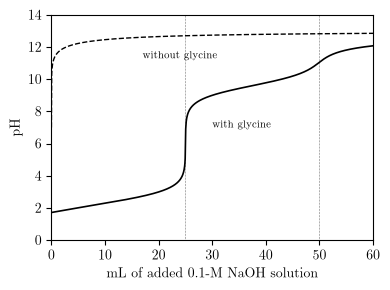

 X (mL)       pH   what is happening
    0.0    1.716   0.1 M glycine HCl, mostly GH2+
   12.5    2.436   half of the first proton removed -> pH near pK1
   25.0    5.989   first equivalence point, essentially all GH
   37.5    9.598   half of the second proton removed -> pH = pK2
   50.0   11.054   second equivalence point, all G-
   60.0   12.074   excess NaOH sets the pH

  the curve is monotonic in X: yes
  a third line for the book's own algebra would be redundant: it agrees with
  the solid curve to 0.013 pH units away from the equivalence points.


In [4]:
X = np.linspace(0.0, 60.0, 1201)
pH_gly, frac = amino_acid_titration(X, glycine, V0, M0, M_BASE, water=True)
pH_water = water_titration_pH(X, V0, M_BASE, water=True)
pH_book, _ = amino_acid_titration(X, glycine, V0, M0, M_BASE)   # the book's own algebra

fig8, ax = plt.subplots(figsize=(4.0, 3.0))
ax.plot(X, pH_water, "--", color="k", lw=1.0)
ax.plot(X, pH_gly, "-", color="k", lw=1.2)
ax.annotate("without glycine", (17, 11.3), fontsize=7)
ax.annotate("with glycine", (30, 7.0), fontsize=7)
# the two equivalence points, in black hairline dots -- the art is pure black ink, so a
# reference rule is separated from the data by weight and dash, not by tint.
for e in (EQ1, EQ2):
    ax.axvline(e, color="k", lw=0.4, ls=":", zorder=0)
ax.set_xlabel("mL of added 0.1-M NaOH solution"); ax.set_ylabel("pH")
ax.set_xlim(0, 60); ax.set_ylim(0, 14)
ax.set_xticks(range(0, 61, 10)); ax.set_yticks(range(0, 15, 2))
fig8.tight_layout(); plt.show()

print(f"{'X (mL)':>7} {'pH':>8}   what is happening")
for x, note in [(0, "0.1 M glycine HCl, mostly GH2+"),
                (12.5, "half of the first proton removed -> pH near pK1"),
                (25, "first equivalence point, essentially all GH"),
                (37.5, "half of the second proton removed -> pH = pK2"),
                (50, "second equivalence point, all G-"),
                (60, "excess NaOH sets the pH")]:
    print(f"{x:7.1f} {float(np.interp(x, X, pH_gly)):8.3f}   {note}")

print(f"\n  the curve is monotonic in X: "
      f"{'yes' if np.all(np.diff(pH_gly) > 0) else 'NO -- that is a bug'}")

# The illustration's own algebra is NOT drawn on the figure, and the reason is that it
# would be invisible: away from the two equivalence points the two agree to 0.013 pH
# units, so a third line would trace the solid one everywhere except for a short
# artifact near X = 50.  Measured, so the claim is checkable:
ok = ~np.isnan(pH_book)
far = ok & (np.abs(X - EQ1) > 5.0) & (np.abs(X - EQ2) > 5.0)
print(f"  a third line for the book's own algebra would be redundant: it agrees with")
print(f"  the solid curve to {np.max(np.abs(pH_gly - pH_book)[far]):.3f} pH units away from"
      f" the equivalence points.")


### What keeping water costs, and what it buys

**It costs nothing the illustration prints.** At $X=0$, 12.5 and 37.5 mL the two forms
agree to three decimals, so pH 1.716, 80.8 % GH$_2^+$, 19.2 % GH and
pH 9.598 $=\mathrm{p}K_2$ all survive intact.

**Where they differ is not symmetric, and it is worth measuring rather than assuming.**
Around the *first* equivalence point the sequential form is wrong only in a sliver -- it
drops from 5.78 to 5.45 as base is added, then recovers within a fraction of a milliliter.
Around the *second* it is wrong over a band about 4 mL wide either side, because S4's
missing 5 mmol of hydroxide compounds the divergence. The cell below prints the measured
extent.

The two anchors that decide it:

1. **The first equivalence point** must be the isoelectric point, where the solution is
   all zwitterion. The proton condition gives **5.989** against
   $(\mathrm{p}K_1+\mathrm{p}K_2)/2=5.97$. The sequential form gives 5.45, and falling.
2. **The second** the sequential form reaches 13.0, breaks, and restarts at 9.1. The
   proton condition passes through **11.05** without a step.

The cure is the one the Comment on Illustration 13.5-2 names for the simpler strong-acid
equations, and Eq. 13.5-7b applies it: keep the water equilibrium.


In [5]:
Xc = np.array([0.0, 12.5, 24.90, 24.99, 25.00, 25.01, 26.0,
               37.5, 49.0, 49.99, 50.00, 50.01, 55.0, 60.0])
pH_seq, _ = amino_acid_titration(Xc, glycine, V0, M0, M_BASE)              # book
pH_ful, _ = amino_acid_titration(Xc, glycine, V0, M0, M_BASE, water=True)  # water kept

print(f"{'X (mL)':>8} {'sequential':>12} {'water kept':>12}   {'diff':>7}")
for x, a, b in zip(Xc, pH_seq, pH_ful):
    shown = "  --  " if np.isnan(a) else f"{a:.3f}"
    diff = "" if np.isnan(a) else f"{b - a:+7.3f}"
    print(f"{x:8.2f} {shown:>12} {b:12.3f}   {diff:>7}")

# how wide is the disagreement, really?  Measured on the plotting grid, not assumed.
seq_all, _ = amino_acid_titration(X, glycine, V0, M0, M_BASE)
ok = ~np.isnan(seq_all)
d = np.abs(pH_gly - seq_all)
bad, runs, prev = X[ok & (d > 0.02)], [], None
for x in bad:
    if prev is None or x - prev > 0.1:
        runs.append([x, x])
    else:
        runs[-1][1] = x
    prev = x
print("\n  the two differ by more than 0.02 pH units only here:")
for lo, hi in runs:
    print(f"    {lo:6.2f} to {hi:6.2f} mL")
far = ok & (np.abs(X - EQ1) > 5.0) & (np.abs(X - EQ2) > 5.0)
print(f"  and 5 mL away from either equivalence point they agree to {np.max(d[far]):.3f}")
print(f"\n  the sequential curve falls as base is added at "
      f"{int(np.sum(np.diff(seq_all[ok]) < 0))} grid points; the corrected one at "
      f"{int(np.sum(np.diff(pH_gly) < 0))}.")


  X (mL)   sequential   water kept      diff
    0.00        1.716        1.716    -0.000
   12.50        2.436        2.436    -0.000
   24.90        4.774        4.773    -0.002
   24.99        5.776        5.665    -0.111
   25.00        5.451        5.989    +0.538
   25.01        6.215        6.313    +0.097
   26.00        8.220        8.219    -0.000
   37.50        9.600        9.598    -0.002
   49.00       10.980       10.804    -0.176
   49.99       12.998       11.051    -1.946
   50.00         --         11.054          
   50.01        9.125       11.057    +1.932
   55.00       11.796       11.809    +0.013
   60.00       12.071       12.074    +0.004

  the two differ by more than 0.02 pH units only here:
     25.00 to  25.00 mL
     46.20 to  49.95 mL
     50.05 to  53.95 mL
  and 5 mL away from either equivalence point they agree to 0.013

  the sequential curve falls as base is added at 1 grid points; the corrected one at 0.


### The buffer plateaus sit on the p$K$s, and that is the check

At the half-way point of each proton removal the two forms flanking it are equally
abundant, so the Henderson-Hasselbalch logarithm vanishes and the pH equals the p$K$.

The second one lands exactly: 9.598 against p$K_2=9.60$. **The first does not, and the
reason is worth knowing** -- it reads 2.436 against p$K_1=2.34$. The half-equivalence
identity assumes the released protons are a negligible correction to the bookkeeping, and
at $X=12.5$ mL they are not: $K_1=4.6\times10^{-3}$ against a glycine concentration of
about $0.067$ M, a ratio of only 15. For $K_2=2.5\times10^{-10}$ the ratio is $10^8$ and
the identity is exact to the digits printed.

That gap is a property of the chemistry, not of the solver: the sequential form and the
proton condition give the same 2.436.


In [6]:
print(f"  pH at X = {EQ1/2:g} mL = {float(np.interp(EQ1/2, X, pH_gly)):.3f}"
      f"   pK1 = {glycine.pK1}")
print(f"  pH at X = {(EQ1 + EQ2)/2:g} mL = {float(np.interp((EQ1+EQ2)/2, X, pH_gly)):.3f}"
      f"   pK2 = {glycine.pK2}")


  pH at X = 12.5 mL = 2.436   pK1 = 2.34
  pH at X = 37.5 mL = 9.598   pK2 = 9.6


## The fractions

Figure 13.6-9 is the same calculation read as a census rather than a pH. In the
illustration's sequential picture the three fractions are straight lines in $X$: each
proton comes off at a constant rate per milliliter of base until it runs out, and the
lines meet at hard corners at $X=25$ and $X=50$ mL.

Keeping water **rounds those corners, and that is the physical answer**. At $X=50$ mL the
sequential form says the glycine is 100 % G$^-$; the proton condition says 96.6 %, with
3.4 % still GH -- because G$^-$ is a weak base and takes a proton back from water. The
largest difference between the two anywhere is 0.034 in a fraction, and it sits exactly at
that corner.

Illustration 13.6-3's list of fractions prints the third one as $f_{\rm GH}=\beta/2.5$;
it is $f_{\rm G^-}$. And the printed figure's first curve label sets as "GH$_2^1$" rather
than GH$_2^+$.


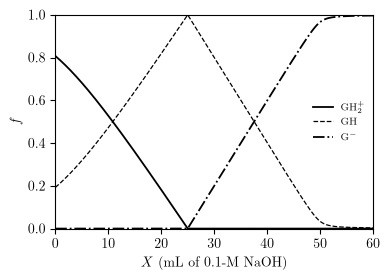

  the fractions sum to 1 everywhere, worst deviation 2.22e-16


In [7]:
fig9, ax = plt.subplots(figsize=(4.0, 2.9))
ax.plot(X, frac[0], "-", color="k", lw=1.3, label=r"GH$_2^+$")
ax.plot(X, frac[1], "--", color="k", lw=0.9, label=r"GH")
ax.plot(X, frac[2], "-.", color="k", lw=1.3, label=r"G$^-$")
ax.set_xlabel(r"$X$  (mL of 0.1-M NaOH)"); ax.set_ylabel(r"$f$")
ax.set_xlim(0, 60); ax.set_ylim(0, 1)
ax.set_xticks(range(0, 61, 10)); ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.legend(frameon=False, fontsize=7, loc="center right")
fig9.tight_layout(); plt.show()

print("  the fractions sum to 1 everywhere, worst deviation "
      f"{np.max(np.abs(frac.sum(axis=0) - 1)):.2e}")


## Past the second equivalence point the illustration loses 5 mmol of hydroxide

Beyond $X=50$ mL there is no glycine left to protonate, so the pH is set by excess base.
The illustration writes

$$M_{\rm OH^-}=\frac{0.1X}{25+X}$$

immediately after the sentence *"all the hydrogen ions resulting from the ionization of
glycine have been neutralized."* Neutralizing them took $2\times2.5=5$ mmol, and that has
to come off:

$$M_{\rm OH^-}=\frac{0.1X-5}{25+X}$$

**Illustration 13.5-8 does exactly this subtraction** in the same situation, writing
$(0.2X-2)/(10+X)$ for a monoprotic acid -- so the omission here is a slip and not a
different convention.

The difference is not subtle. And Fig. 13.6-8 settles it: the printed form would put the
curve flat at 12.83 immediately past 50 mL, while the figure leaves the plateau near 11.


 X (mL)   as printed   corrected
   50.5       12.825      10.821
   52.0       12.830      11.415
   55.0       12.837      11.796
   60.0       12.849      12.071


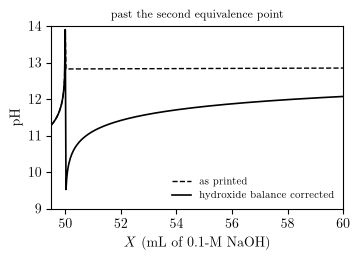

In [8]:
Xa = np.array([50.5, 52.0, 55.0, 60.0])
pH_c, _ = amino_acid_titration(Xa, glycine, V0, M0, M_BASE)
pH_p, _ = amino_acid_titration(Xa, glycine, V0, M0, M_BASE, printed=True)
print(f"{'X (mL)':>7} {'as printed':>12} {'corrected':>11}")
for x, a, b in zip(Xa, pH_p, pH_c):
    print(f"{x:7.1f} {a:12.3f} {b:11.3f}")

Xz = np.linspace(49.5, 60.0, 401)
pc, _ = amino_acid_titration(Xz, glycine, V0, M0, M_BASE)
pp, _ = amino_acid_titration(Xz, glycine, V0, M0, M_BASE, printed=True)

fig, ax = plt.subplots(figsize=(3.7, 2.7))
ax.plot(Xz, pp, "--", color="k", lw=1.0, label="as printed")
ax.plot(Xz, pc, "-", color="k", lw=1.2, label="hydroxide balance corrected")
ax.set_xlabel(r"$X$  (mL of 0.1-M NaOH)"); ax.set_ylabel("pH")
ax.set_xlim(49.5, 60); ax.set_ylim(9, 14)
ax.legend(frameon=False, fontsize=7, loc="lower right")
ax.set_title("past the second equivalence point", fontsize=8)
fig.tight_layout(); plt.show()


## And a disagreement in the same figure -- now identified

Between the two equivalence points -- $25<X<50$ mL -- the illustration's own equations put
the second buffer plateau on p$K_2=9.60$, rising from 8.22 at $X=26$ to 10.80 at $X=49$.
That is what a buffer region does. **The printed Fig. 13.6-8 is flat there**: traced off the
page at 600 dpi it rises **0.35 pH units across $30<X<50$ mL**, about two line widths.

The two cannot both be right, and the staged 6e art follows the equations. **What drew the
printed branch is now known**, and it is worth understanding because the same mistake is
easy to make:

$$M_{\rm OH^-}=\sqrt{K_2\,f_{\rm G^-}\times 0.1\ {\rm M}}$$

**The form is right and the constant is wrong.** At $X=50$ mL the solution really is a
weak-base salt -- 0.033-M sodium glycinate -- and the hydrolysis formula $\sqrt{K_b C}$
gives 11.061 where the full proton condition gives 11.054. But:

1. **$K_2$ sits under the radical where $K_b=K_w/K_2$ belongs** -- an *acid* dissociation
   constant used as a *base* hydrolysis constant. That makes $M_{\rm OH^-}$ too small by
   $\sqrt{K_w}/K_2 = 398$, which is **2.60 pH units at every $X$**. That one line is the
   whole gap.
2. **The concentration is the fraction times the *initial* 0.1 M**, so dilution by the
   added titrant is ignored: $+0.24$ pH at $X=50$.

$11.06 \to 8.46 \to 8.70$, against **8.73** traced.

**And that is why it looks like an asymptote.** The formula is applied across the whole
buffer region, where a buffer equation belongs. Since it goes as $\sqrt{C}$ and
$C\propto\beta=0.1X-2.5$,

$$\mathrm{pH}=\text{const}+\tfrac12\log_{10}(0.1X-2.5)$$

-- a logarithm of a linear ramp, halved: steep just past $X=25$, flat after. A real buffer
follows $\log_{10}[\beta/(n_0-\beta)]$, and *that* ratio runs to infinity at $X=50$. The
difference between a concentration that doubles and a ratio that diverges is the 2.6 pH
units the equations rise and the printed art does not.

The trace, the candidate scoring, and the calibration that makes them trustworthy are in
`validation/ionization_module_validation.ipynb`, which reads the printed page directly.


In [9]:
Xb = np.array([26.0, 30.0, 37.5, 45.0, 49.0])
pb, _ = amino_acid_titration(Xb, glycine, V0, M0, M_BASE)
pw, _ = amino_acid_titration(Xb, glycine, V0, M0, M_BASE, water=True)
# the last column is TRACED off the printed page at 600 dpi, not read by eye; the trace
# and its calibration are in validation/ionization_module_validation.ipynb
traced = np.array([7.78, 8.38, 8.49, 8.63, 8.71])
print(f"{'X (mL)':>7} {'sequential':>12} {'water kept':>12} {'5e printed':>12}")
for x, p, q, t in zip(Xb, pb, pw, traced):
    print(f"{x:7.1f} {p:12.3f} {q:12.3f} {t:12.2f}")

print(f"\n  the equations rise {pw[-1] - pw[0]:.2f} pH units from X = 26 to 49 mL.")
print(f"  the printed curve rises {traced[-1] - traced[1]:.2f} over 30 to 49 -- flat.")
print("\n  keeping water does NOT close this gap: both forms sit on pK2 = 9.60.")

# the shape is the evidence: half a decade of pH per decade of beta is a square-root law,
# where a Henderson-Hasselbalch buffer gives one per decade of the ratio.
beta = 0.1 * np.array([30.0, 50.0]) - N0
print(f"\n  over 30 to 50 mL, beta runs {beta[0]:.1f} to {beta[1]:.1f} mmol"
      f" = {np.log10(beta[1] / beta[0]):.2f} decades;")
print(f"  a square-root law predicts a rise of {0.5 * np.log10(beta[1] / beta[0]):.2f} pH,"
      f" and the trace measures 0.35.")


 X (mL)   sequential   water kept   5e printed
   26.0        8.220        8.219         7.78
   30.0        8.998        8.997         8.38
   37.5        9.600        9.598         8.49
   45.0       10.202       10.190         8.63
   49.0       10.980       10.804         8.71

  the equations rise 2.58 pH units from X = 26 to 49 mL.
  the printed curve rises 0.33 over 30 to 49 -- flat.

  keeping water does NOT close this gap: both forms sit on pK2 = 9.60.

  over 30 to 50 mL, beta runs 0.5 to 2.5 mmol = 0.70 decades;
  a square-root law predicts a rise of 0.35 pH, and the trace measures 0.35.


## The disagreement is not only in the art -- the text describes the flat figure too

The paragraph that walks the reader along Fig. 13.6-8 makes six checkable claims. **Four
hold and two do not**, and the two that fail are the *same* disagreement as the flat
plateau above, reaching into the prose:

> *"Further addition of NaOH results in a sharp increase in pH to slightly above pH = 8.
> Then continued additions of the strong base lead to the release of hydrogen ions from
> the amino groups … resulting in **only a slight increase in pH** until 50 mL of NaOH
> solution has been added. At that point … the pH of the solution **increases rapidly**.
> … glycine … is an effective buffer in the pH range near 2 and also in the pH range
> **slightly above 8**."*

The equations say otherwise on all three highlighted phrases. Between 26 and 49 mL the pH
rises **2.6 units**, which is a buffer region doing exactly what a buffer region does --
not a "slight increase." The second buffer sits on p$K_2=9.60$, not "slightly above 8."

And the last one is the more interesting failure, because it is a real feature of this
system rather than a mis-drawn curve: **past 50 mL the pH does not increase rapidly.** It
gains 1.0 unit over 10 mL, and by the slope measure below it is the *flattest* stretch of
the whole curve -- flatter than the second buffer region itself. There is no sharp break
at the second equivalence point at all, because $\mathrm{p}K_2=9.6$ is too close to the
pH of the sodium glycinate solution it produces (11.05) for one to exist.

**This matters for the redraw.** Correcting the curve is not enough on its own: the
paragraph was written to the flat figure, so whichever way the art goes, these three
phrases have to go with it.


In [10]:
Xf = np.linspace(0.0, 60.0, 6001)
pf, _ = amino_acid_titration(Xf, glycine, V0, M0, M_BASE, water=True)
at = lambda x: float(np.interp(x, Xf, pf))

claims = [
    ("without glycine, initially pH 7",
     f"{float(water_titration_pH(0.0, V0, M_BASE, water=True)):.2f}", True),
    ("with glycine the initial pH is low", f"{at(0):.2f}", True),
    ("remains low until 25 mL", f"{at(0):.2f} to {at(24):.2f}", True),
    ("sharp increase to slightly above pH 8", f"{at(24):.2f} -> {at(26):.2f}", True),
    ("only a SLIGHT increase until 50 mL",
     f"{at(26):.2f} -> {at(49):.2f}, a rise of {at(49) - at(26):.2f}", False),
    ("buffers near 2 and SLIGHTLY ABOVE 8",
     f"pK1 = {glycine.pK1}, pK2 = {glycine.pK2}", False),
    ("past 50 mL the pH increases RAPIDLY",
     f"{at(50):.2f} -> {at(60):.2f}, a rise of {at(60) - at(50):.2f} over 10 mL", False),
]
print("Illustration 13.6-3's closing paragraph, claim by claim\n" + "-" * 74)
for text, found, holds in claims:
    print(f"  {'holds' if holds else 'FAILS':>5}  {text:38s} {found}")

# a buffer region is the FLATTEST part of a titration curve; measure the slopes
slope = np.gradient(pf, Xf)
print("\nmean dpH/dmL by interval -- a buffer should be the smallest:")
for lo, hi, label in [(1, 24, "buffer 1   (0-25 mL)"),
                      (26, 49, "buffer 2   (25-50 mL)"),
                      (51, 60, "past 50 mL")]:
    m = (Xf >= lo) & (Xf <= hi)
    print(f"  {label:22s} {slope[m].mean():.3f}")
print("\n  past 50 mL is FLATTER than the second buffer region, so the paragraph's")
print("  'increases rapidly' describes a break this system does not have: pK2 = 9.60")
print(f"  is too close to the pH of the sodium glycinate it makes ({at(50):.2f}).")


Illustration 13.6-3's closing paragraph, claim by claim
--------------------------------------------------------------------------
  holds  without glycine, initially pH 7        7.00
  holds  with glycine the initial pH is low     1.72
  holds  remains low until 25 mL                1.72 to 3.76
  holds  sharp increase to slightly above pH 8  3.76 -> 8.22
  FAILS  only a SLIGHT increase until 50 mL     8.22 -> 10.80, a rise of 2.58
  FAILS  buffers near 2 and SLIGHTLY ABOVE 8    pK1 = 2.34, pK2 = 9.6
  FAILS  past 50 mL the pH increases RAPIDLY    11.05 -> 12.07, a rise of 1.02 over 10 mL

mean dpH/dmL by interval -- a buffer should be the smallest:
  buffer 1   (0-25 mL)   0.086
  buffer 2   (25-50 mL)  0.112
  past 50 mL             0.087

  past 50 mL is FLATTER than the second buffer region, so the paragraph's
  'increases rapidly' describes a break this system does not have: pK2 = 9.60
  is too close to the pH of the sodium glycinate it makes (11.05).


## The deliverable art

`Figure_13.6-8.pdf` and `Figure_13.6-9.pdf`, written at the book's figure size in
Computer Modern, pure black ink. They are staged as `c13f021.pdf` and `c13f022.pdf`.

Note what staging Fig. 13.6-8 commits to: it is the redrawn curve, on p$K_2=9.60$, so it
**settles the open question about that figure in the direction of the equations**. The
three phrases audited two cells above have to change with it.


In [11]:
os.makedirs("pdf", exist_ok=True)
for fig, name in ((fig8, "Figure_13.6-8"), (fig9, "Figure_13.6-9")):
    path = f"pdf/{name}.pdf"
    fig.savefig(path, dpi=300, bbox_inches="tight")
    print(f"  wrote {path}")
print(f"\n  typography: {'LaTeX' if plt.rcParams['text.usetex'] else 'mathtext'}"
      f" Computer Modern")


  wrote pdf/Figure_13.6-8.pdf


  wrote pdf/Figure_13.6-9.pdf

  typography: LaTeX Computer Modern


## Your turn

1. `water=True` solves the two equilibria *simultaneously* and keeps water; the default
   solves them in sequence and drops it. Plot the difference between the two over the whole
   titration and find every $X$ where it exceeds 0.05 pH units. You should get two narrow
   windows and nothing else -- say why those two and not, for instance, the middle of a
   buffer plateau.
2. The sequential form errs toward pH 13 just before $X=50$ mL where the answer is 11.05.
   Show that dropping water can only ever err in that direction -- that is, that the sign
   of the error is not an accident of these particular p$K$s.
3. At the first equivalence point the proton condition gives pH 5.989 and the isoelectric
   point is $(\mathrm{p}K_1+\mathrm{p}K_2)/2=5.97$. They are close but not equal. Which
   assumption behind the p$I$ formula is doing the work, and at what concentration would
   the two agree to three decimals?
4. Glycine buffers around pH 2.4 and 9.6, and biology mostly happens near 7.4. Which amino
   acid side chain has a p$K$ near 7.4, and what does that make it useful for?
5. Repeat the titration with histidine (p$K$ = 1.82, 6.00, 9.17) and show that a triprotic
   amino acid gives three plateaus. Then say which of the three is useful as a
   physiological buffer.
6. Derive the general result that at the $j$-th half-equivalence point of a polyprotic acid
   the pH equals p$K_j$, and state the condition on the p$K$ spacing *and on the
   concentration* under which it fails. Check your condition against the 2.436 this
   notebook reads at $X=12.5$ mL.
